In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

In [23]:
fund = pd.read_csv("../data/processed/clean_01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

aum = pd.read_csv("../data/processed/clean_03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/clean_04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/clean_05_category_inflows.csv")

folio = pd.read_csv("../data/processed/clean_06_industry_folio_count.csv")

portfolio = pd.read_csv("../data/processed/clean_09_portfolio_holdings.csv")

In [24]:
print(nav.columns.tolist())

['amfi_code', 'nav']


In [25]:

print(nav.head())

   amfi_code       nav
0     100016  520.4608
1     100016  515.0971
2     100016  521.7239
3     100016  515.7880
4     100016  515.1639


In [26]:
raw_nav = pd.read_csv("../data/raw/02_nav_history.csv")

clean_nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

In [27]:
nav = raw_nav[["amfi_code", "date"]].copy()

nav["nav"] = clean_nav["nav"]

nav["date"] = pd.to_datetime(nav["date"])

print(nav.head())

   amfi_code       date       nav
0     119551 2022-01-03  520.4608
1     119551 2022-01-04  515.0971
2     119551 2022-01-05  521.7239
3     119551 2022-01-06  515.7880
4     119551 2022-01-07  515.1639


In [28]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [29]:
nav["date"] = pd.to_datetime(nav["date"])

In [30]:
nav = nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code"
)

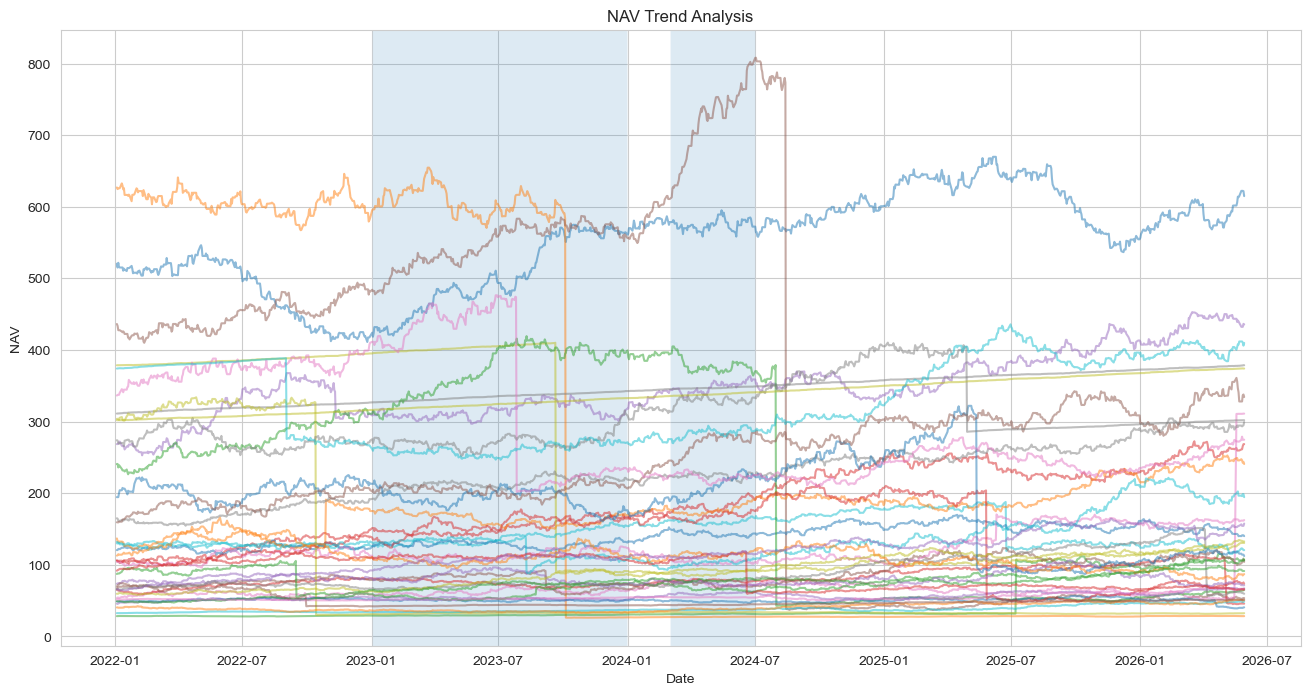

In [31]:
plt.figure(figsize=(16,8))

for scheme in nav["scheme_name"].unique():
    temp = nav[nav["scheme_name"] == scheme]
    plt.plot(temp["date"], temp["nav"], alpha=0.5)

plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.15,
    label="2023 Bull Run"
)

plt.axvspan(
    pd.Timestamp("2024-03-01"),
    pd.Timestamp("2024-06-30"),
    alpha=0.15,
    label="2024 Correction"
)

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.savefig(
    "../reports/charts/nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
aum = pd.read_csv(
    "../data/processed/clean_03_aum_by_fund_house.csv"
)

aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

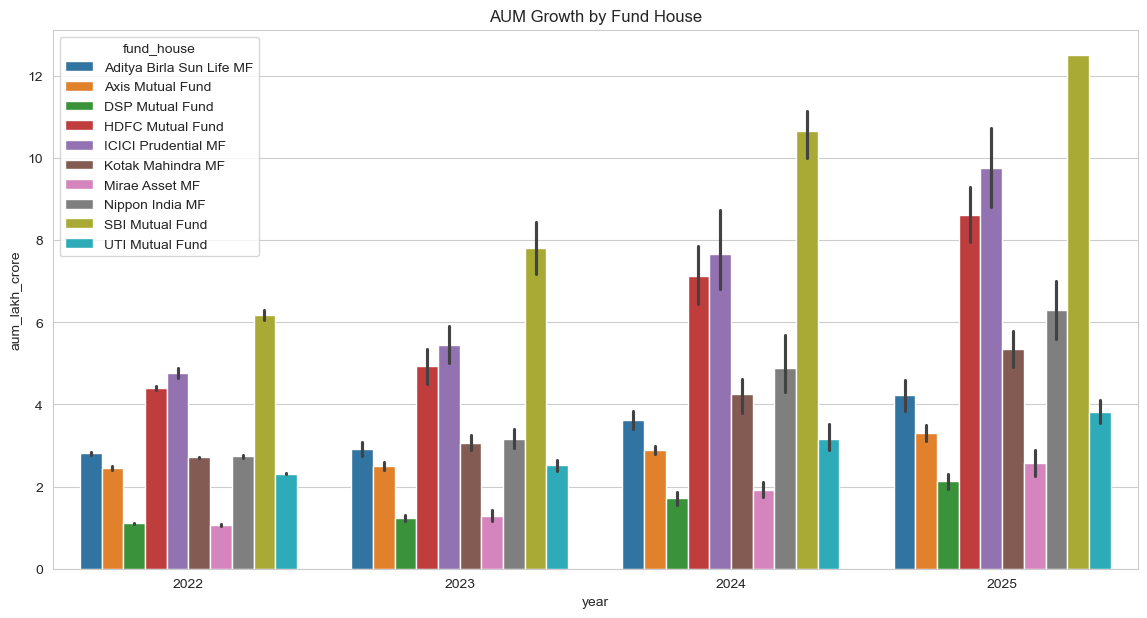

In [33]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
sip = pd.read_csv(
    "../data/processed/clean_04_monthly_sip_inflows.csv"
)

sip["month"] = pd.to_datetime(
    sip["month"]
)

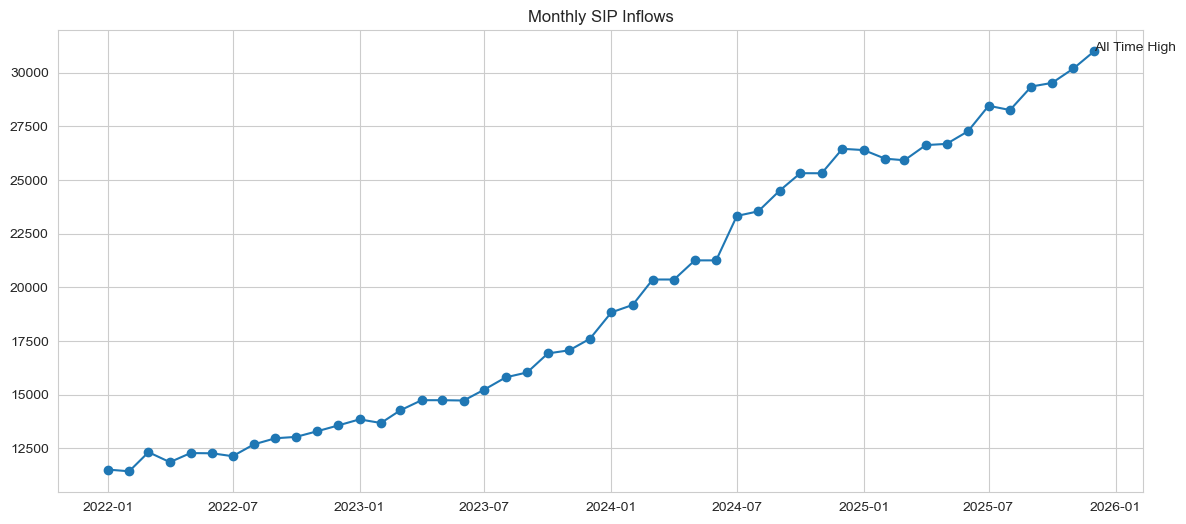

In [35]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

max_idx = sip["sip_inflow_crore"].idxmax()

plt.annotate(
    "All Time High",
    (
        sip.loc[max_idx,"month"],
        sip.loc[max_idx,"sip_inflow_crore"]
    )
)

plt.title("Monthly SIP Inflows")

plt.savefig(
    "../reports/charts/sip_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
category = pd.read_csv(
    "../data/processed/clean_05_category_inflows.csv"
)

pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

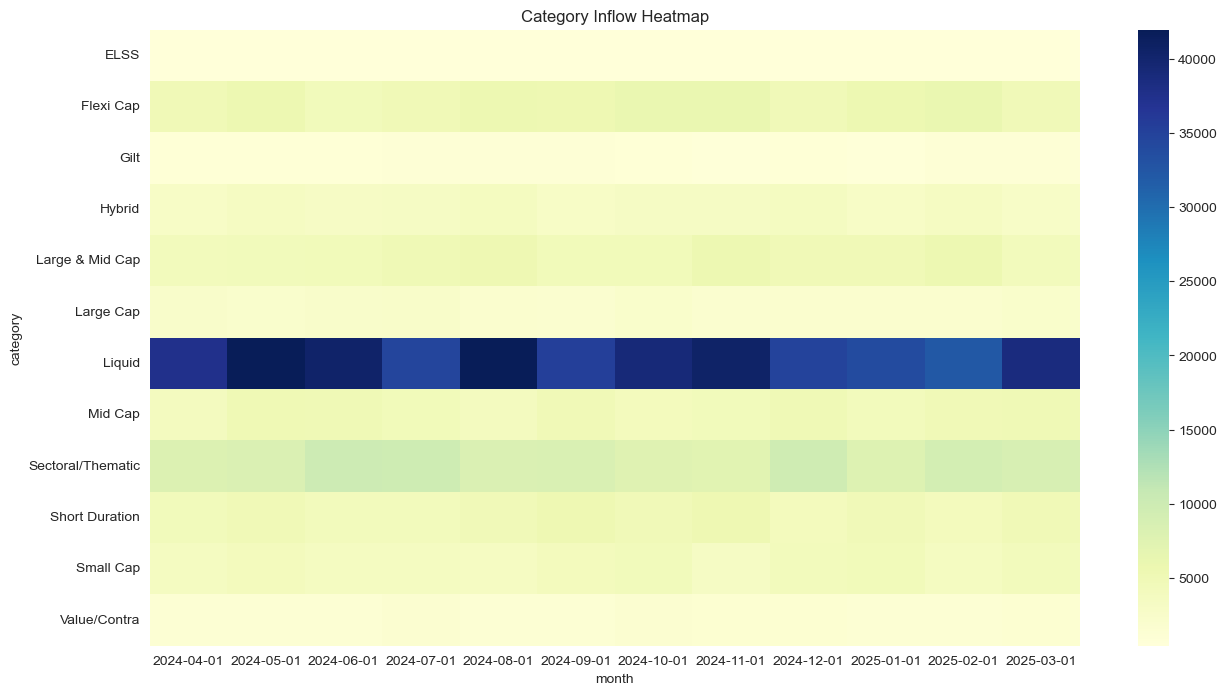

In [37]:
plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "../reports/charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
trans = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

print(trans.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


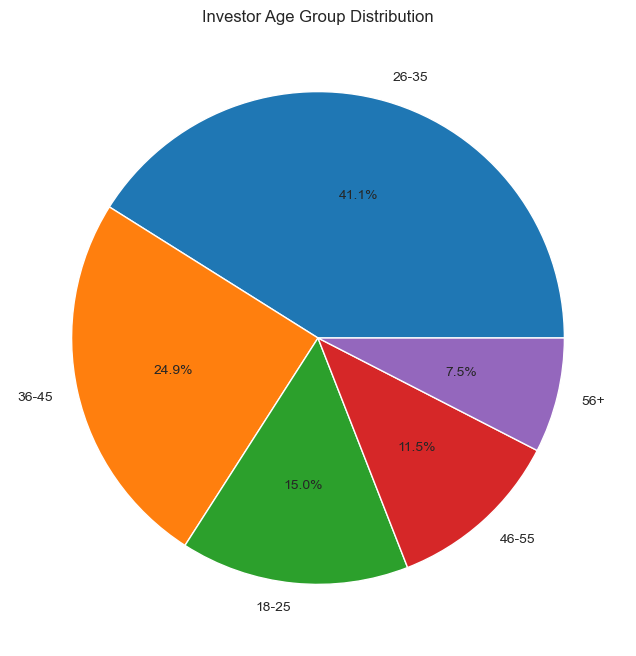

In [39]:
trans = pd.read_csv("../data/processed/clean_transactions.csv")

age_dist = trans["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

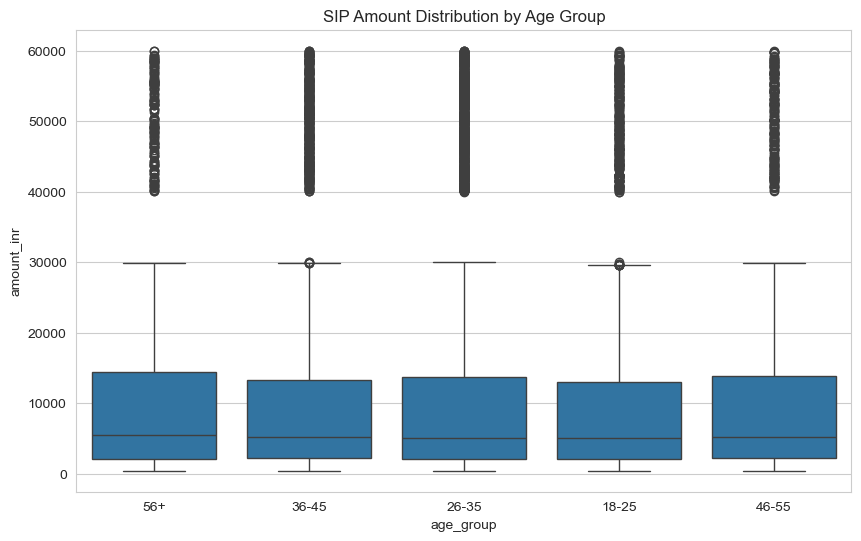

In [40]:
sip_data = trans[
    trans["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.savefig(
    "../reports/charts/sip_boxplot_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

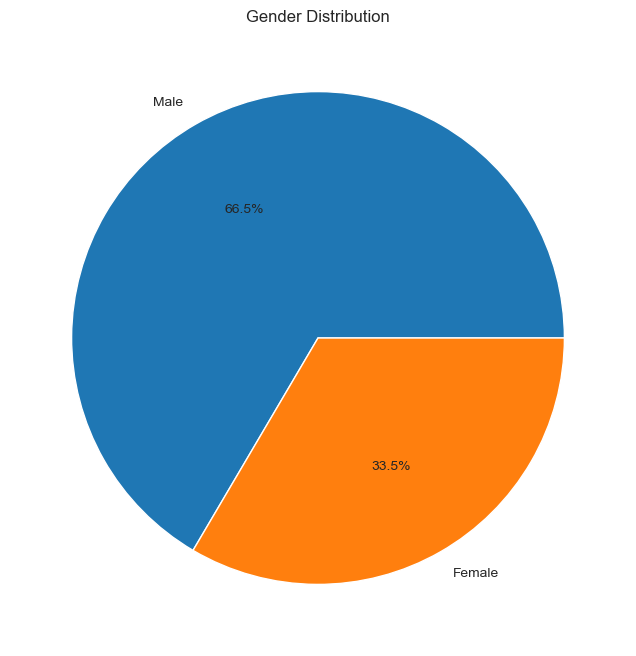

In [41]:
gender = trans["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

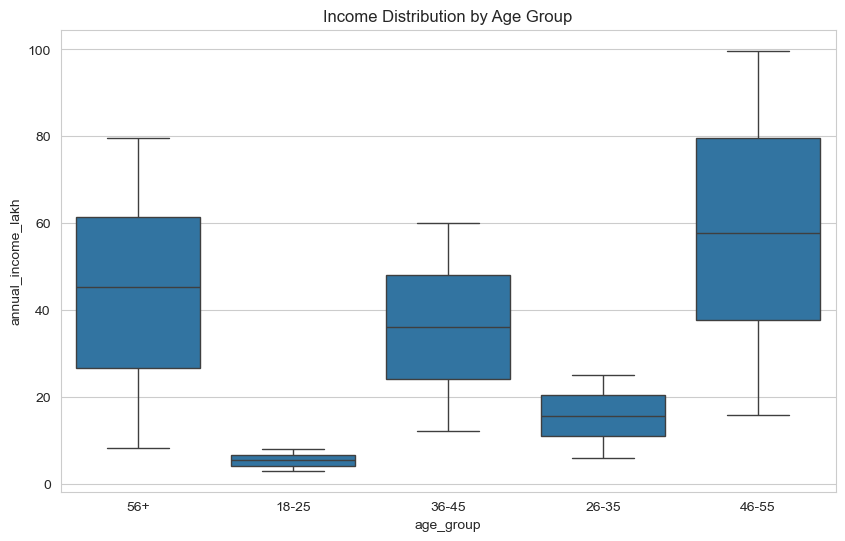

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=trans,
    x="age_group",
    y="annual_income_lakh"
)

plt.title("Income Distribution by Age Group")

plt.savefig(
    "../reports/charts/income_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

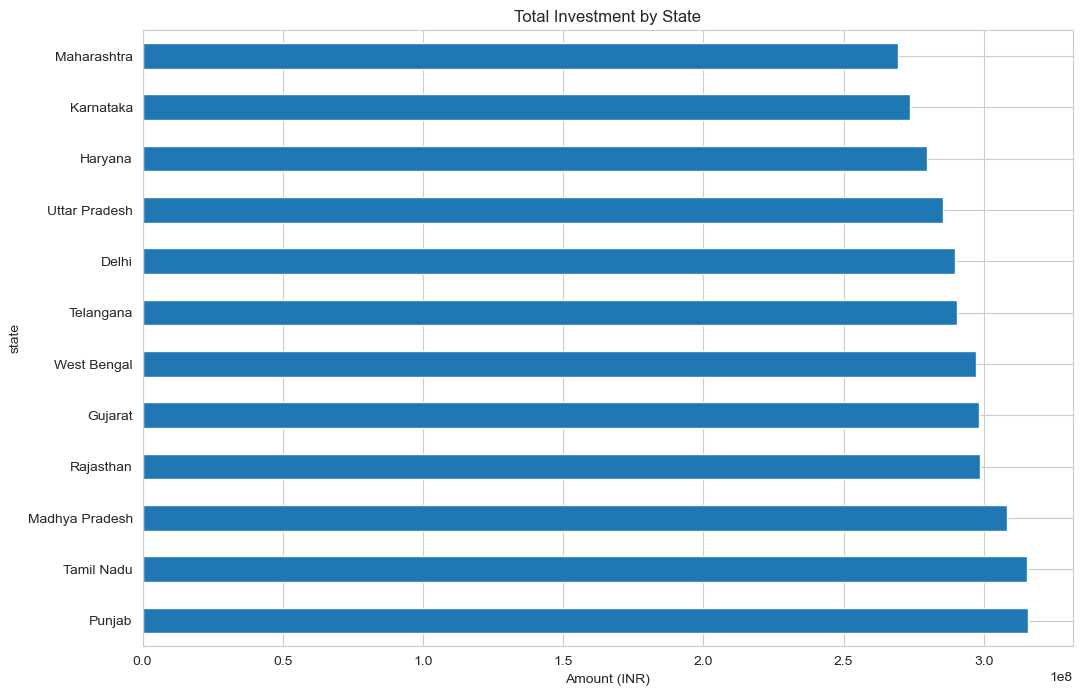

In [43]:
state_sip = (
    trans.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_sip.plot.barh()

plt.title("Total Investment by State")

plt.xlabel("Amount (INR)")

plt.savefig(
    "../reports/charts/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

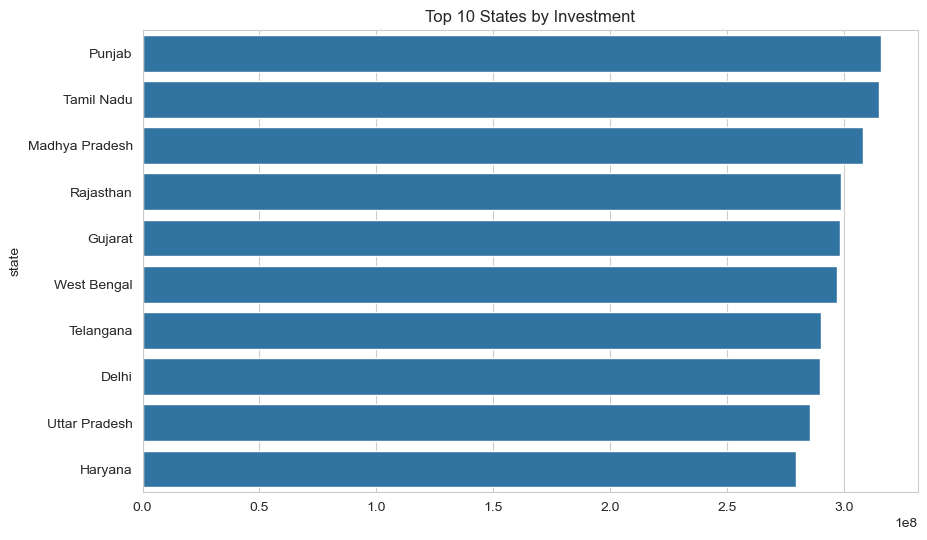

In [44]:
top10 = state_sip.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States by Investment")

plt.savefig(
    "../reports/charts/top10_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

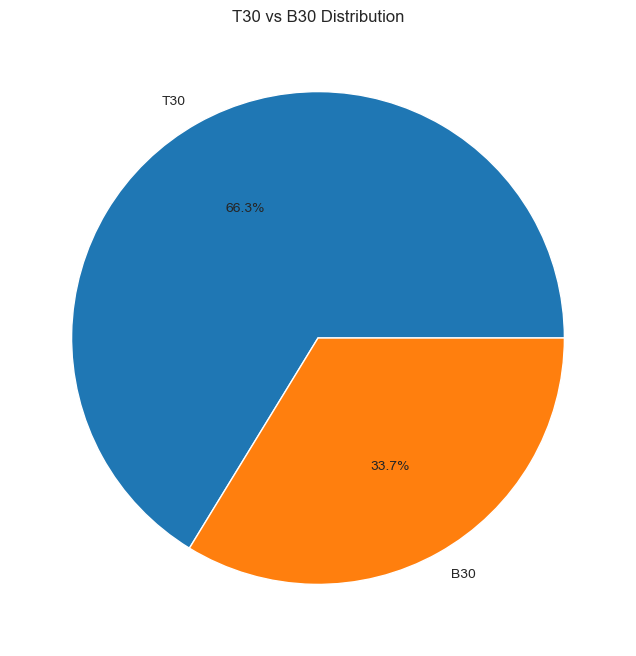

In [45]:
tier = trans["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

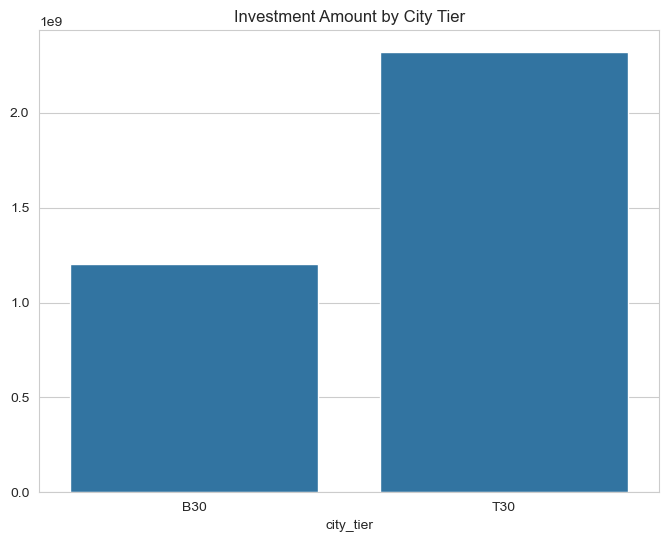

In [46]:
tier_amount = (
    trans.groupby("city_tier")["amount_inr"]
    .sum()
)

plt.figure(figsize=(8,6))

sns.barplot(
    x=tier_amount.index,
    y=tier_amount.values
)

plt.title("Investment Amount by City Tier")

plt.savefig(
    "../reports/charts/city_tier_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

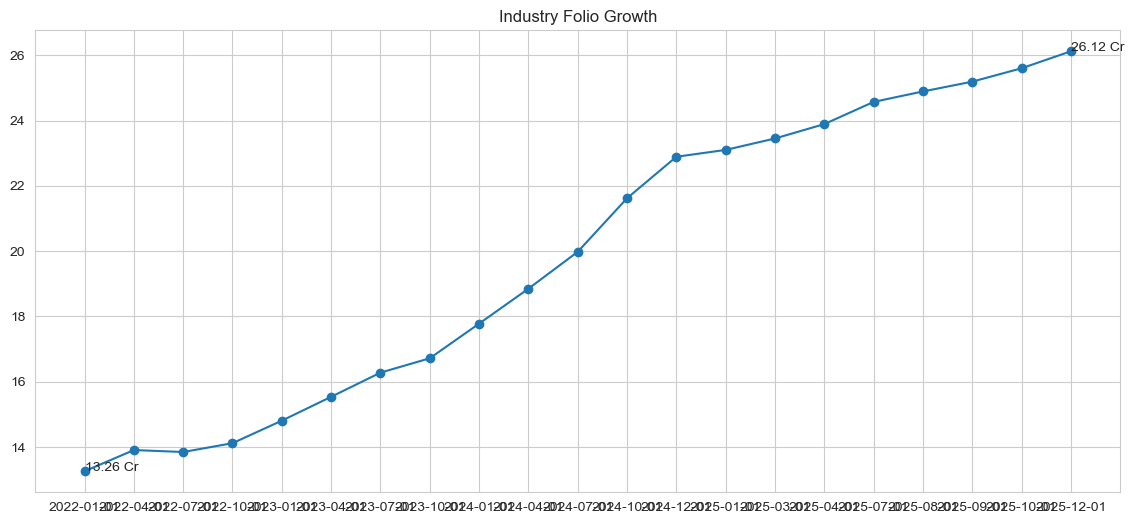

In [47]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.annotate(
    "13.26 Cr",
    (folio.iloc[0]["month"],
     folio.iloc[0]["total_folios_crore"])
)

plt.annotate(
    "26.12 Cr",
    (folio.iloc[-1]["month"],
     folio.iloc[-1]["total_folios_crore"])
)

plt.title("Industry Folio Growth")

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
top10 = nav["scheme_name"].unique()[:10]

In [49]:
temp = nav[
    nav["scheme_name"].isin(top10)
]

In [50]:
pivot = temp.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

In [51]:
returns = pivot.pct_change()

corr = returns.corr()

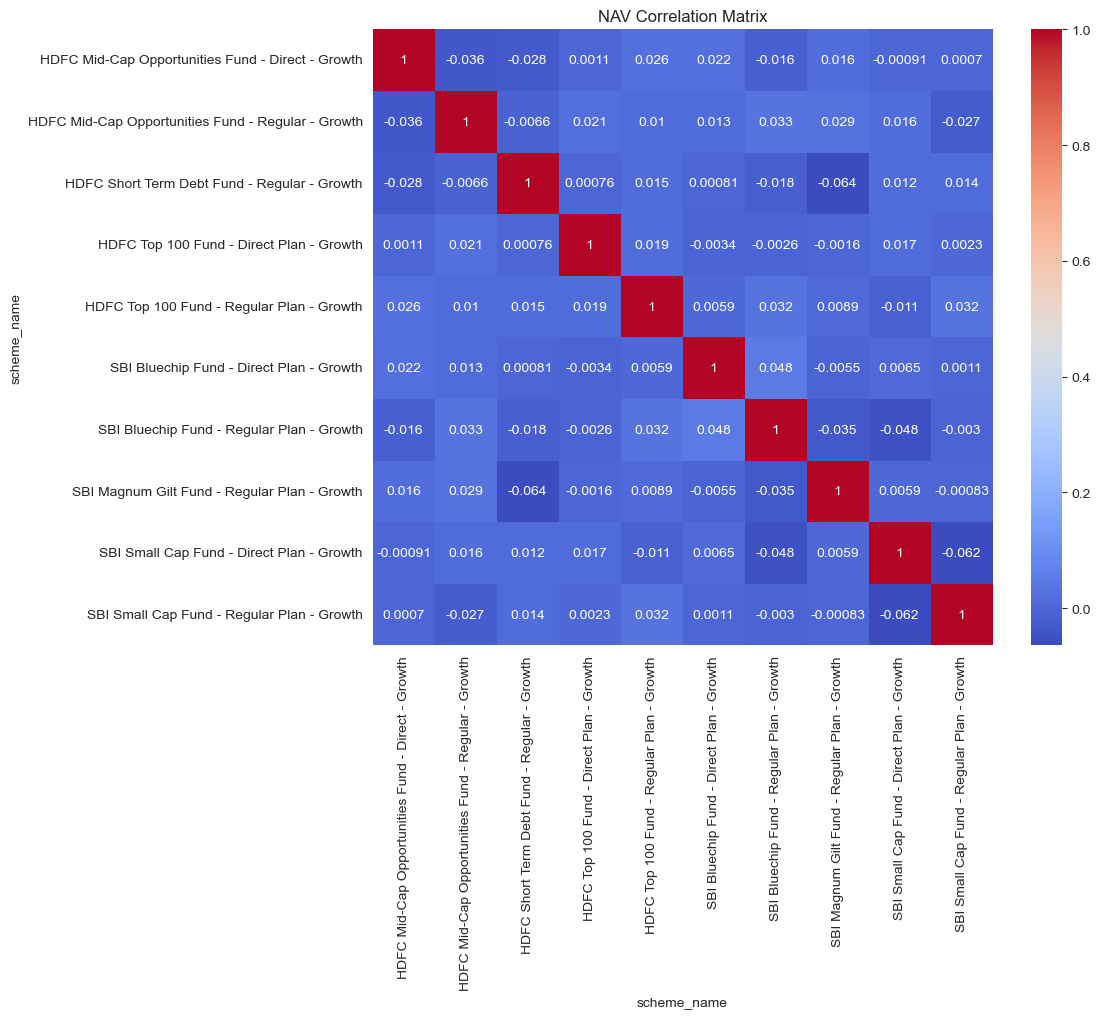

In [52]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Correlation Matrix")

plt.savefig(
    "../reports/charts/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
portfolio = pd.read_csv(
    "../data/processed/clean_09_portfolio_holdings.csv"
)

sector = (
    portfolio
    .groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

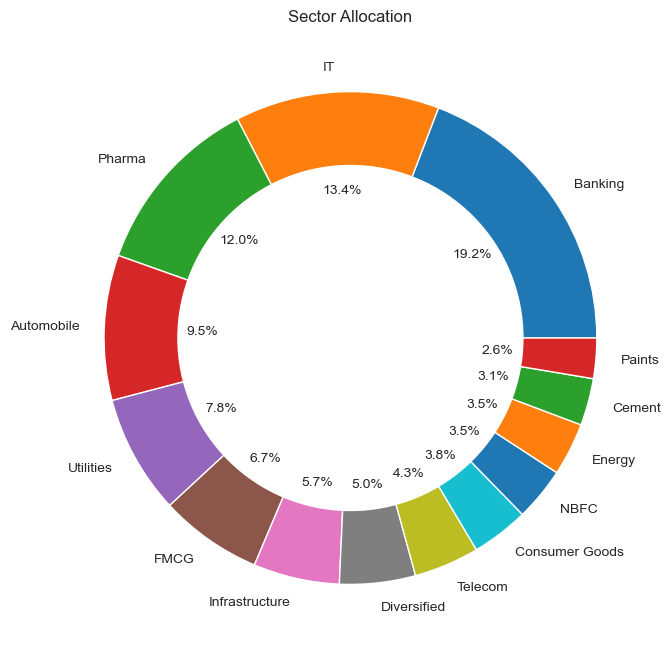

In [54]:
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

plt.gca().add_artist(circle)

plt.title("Sector Allocation")

plt.savefig(
    "../reports/charts/sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SBI Mutual Fund maintained the highest AUM among all AMCs from 2022–2025.

Monthly SIP inflows showed a consistent upward trend and reached an all-time high in Dec 2025.

Investors aged 26–35 formed the largest share of mutual fund investors.

T30 cities contributed the majority of investment volume.

Equity folios accounted for the largest share of industry folios.

Technology and Banking sectors dominated portfolio allocations.

Most large-cap funds exhibited strong positive NAV correlations.

Category inflows were concentrated in Flexi Cap and Mid Cap funds.

Industry folio count nearly doubled between 2022 and 2025.

Higher-income investors generally invested larger transaction amounts.